# ***⋆ ۶ৎ ݁˖ WELCOME TO BENISSE YONIKA'S NOTEBOOK! ݁˖ ۶ৎ ⋆***

## **ECE 2112**: *ADVANCED COMPUTER PROGRAMMING AND ALGORITHMS*

### **PROGRAMMING ASSIGNMENT #4**

> **Name:** Benisse Yonika C. De Vera

> **Section:** 2ECE-B

> **Date Submitted**: September 16, 2026

## **PROBLEM A: VISAYAS COMMUNICATION DATAFRAME**

- Create a DataFrame named **VisComm** containing students whose Hometown is **Visayas** and whose Track is **Communication**. Retain only these columns, in the stated order:

> `Name, Gender, Math, Electronics, Average`

> **Requirement**: Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to the source dataset before the columns are selected.


### **Code Explanation**:
> `import pandas as pd` imports the Pandas library for data manipulation and assigns it the alias `pd`.

> `import matplotlib.pyplot as plt` imports the pyplot module from the Matplotlib library for creating visualizations and assigns it the alias `plt`.

> `board = pd.read_excel("board2.xlsx")` reads the comma-separated values file and loads the ECE Board Exam 2 dataset into a DataFrame named ad `df`.

> `(board['Hometown']] == 'Visayas') & (board['Track']] == 'Communication')` applies two explicit conditions using the bitwise **AND** operator (`&`) to filter students from Visayas enrolled in the Communication track.

> `[['Name', 'Gender', 'Math', 'Electronics', 'Average']]` selects and reorders the specified target columns from the filtered result.

> `VisComm = ...` stores the resulting filtered table into a new DataFrame named `VisComm` without modifying `board`.

> `display(VisComm)` renders the tabular DataFrame output in Jupyter Notebook.

> `len(VisComm)` calculates and outputs the total number of rows present in the `VisComm` DataFrame.



### **Actual Code**:

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

board = pd.read_excel("board2.xlsx")

In [25]:
board.columns = board.columns.str.strip()

if "Average" not in board.columns:
  board["Average"] = board[["Math", "GEAS", "Electronics"]].mean(axis=1)

In [26]:
VisComm = board[
    (board["Hometown"] =="Visayas") & (board["Track"] == "Communication")
][["Name", "Gender", "Math", "Electronics", "Average"]]

display(VisComm)

print(f"Number of rows in VisComm: {len(VisComm)}")

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,50.666667
11,S12,Male,89,67,80.000000
17,S18,Male,81,40,67.333333
21,S22,Female,64,39,64.000000
27,S28,Male,85,53,72.666667


Number of rows in VisComm: 5


## **PROBLEM B: VISAYAS FEMALE DATAFRAME**

- Create a second DataFrame named **VisFemale** containing students whose Hometown is **Visayas** and whose Gender is **Female**. Retain only:

> `Name, Track, GEAS, Electronics, Average`

> **Requirement**: Display **VisFemale**. Then display only the rows of **VisFemale** whose Average is **at least 60**. Do not overwrite VisFemale when performing this second filter.


### **Code Explanation**:
> `(board['Hometown'] == 'Visayas') & (board['Gender'] == 'Female')` filters the original DataFrame for students whose Hometown is Visayas and whose Gender is Female.

> `[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]` selects only the required columns for the `VisFemale` DataFrame.

> `VisFemale[VisFemale['Average'] >= 60]` evaluates and displays a temporary view of students in `VisFemale` with an `Average` score of 60 or higher without altering `VisFemale`.



### **Actual Code**:

In [27]:
VisFemale = board[
    (board["Hometown"] == "Visayas") & (board["Gender"] == "Female")
][["Name", "Track", "GEAS", "Electronics", "Average"]]

display(VisFemale)

display(VisFemale[VisFemale["Average"] >= 60])

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,73.000000
10,S11,Communication,48,56,50.666667
20,S21,Microelectronics,68,51,67.333333
21,S22,Communication,89,39,64.000000
23,S24,Microelectronics,60,45,63.333333
25,S26,Instrumentation,83,47,67.000000


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,73.000000
20,S21,Microelectronics,68,51,67.333333
21,S22,Communication,89,39,64.000000
23,S24,Microelectronics,60,45,63.333333
25,S26,Instrumentation,83,47,67.000000


## **PROBLEM C: CATEGORY-AVERAGE VISUALIZATION**

- Examine how the recorded Average differs across the three categorical features Track, Gender, and Hometown.

a. For each feature, compute the mean of Average for every category using Pandas.

b. Display the three summary tables.

c. Create one figure containing three bar charts: mean Average by Track, by Gender, and by Hometown.

d. Below the figure, write three concise statements identifying the category with the highest sample mean for each feature.

> **Interpretation Rule**: Describe the observed dataset only. A difference in group means does not, by itself, establish that a feature causes a higher board-exam score.


### **Code Explanation**:
> `board.groupby('Track')['Average'].mean().reset_index()` groups data by `Track`, calculates the mean `Average` score for each category, and formats the output into a clean DataFrame.

> `plt.subplots(1, 3, figsize=(15, 5), shaarey=True)` creates a single figure with 3 subplots side-by-side sharing a unuform vertical scale.

> `axes[0].bar(...)` generates a vertical bar plot displaying category means on the specified subplot axis.

> `axes[0].set_title(), set_xlabel(), and set_ylabel()` assign informative labels and plot titles to maintain visual clarity.

> `plt.tight_layout()` auto-adjusts padding between subplots to prevent overlapping text and axis labels.



### **Actual Code**:

In [28]:
track_mean = board.groupby("Track")["Average"].mean().reset_index()
gender_mean = board.groupby("Gender")["Average"].mean().reset_index()
hometown_mean = board.groupby("Hometown")["Average"].mean().reset_index()

In [ ]:
print("Mean Average by Track:")
display(track_mean)

print("\nMean Average by Gender:")
display(gender_mean)

print("\nMean Average by Hometown:")
display(hometown_mean)

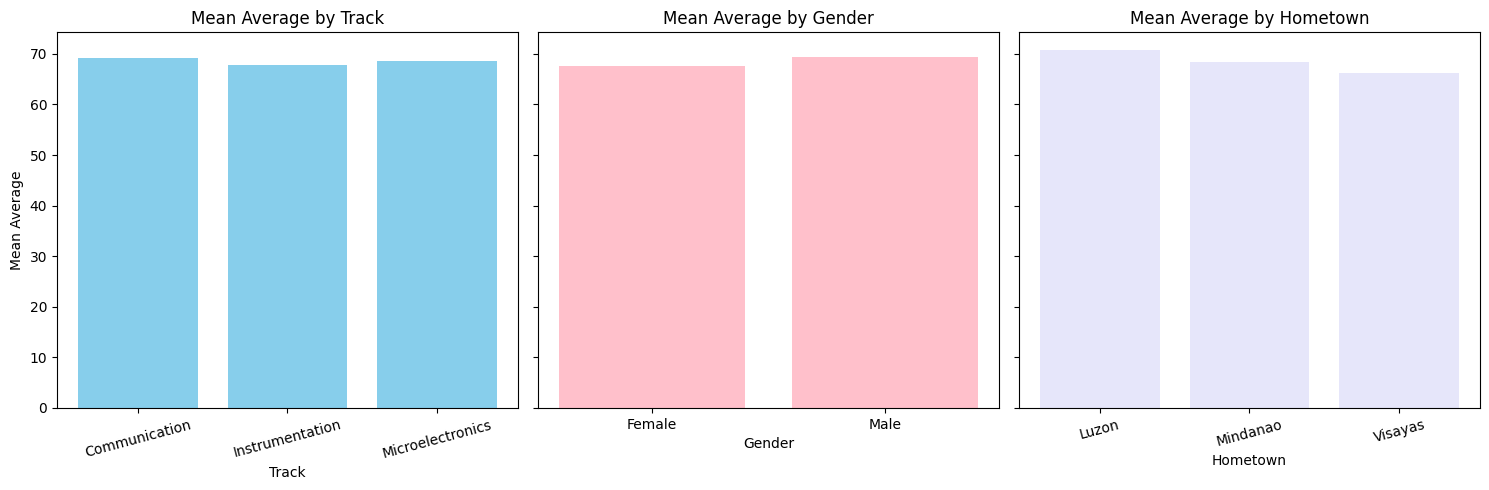

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axes[0].bar(track_mean["Track"], track_mean["Average"], color="skyblue")
axes[0].set_title("Mean Average by Track")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(gender_mean["Gender"], gender_mean["Average"], color="pink")
axes[1].set_title("Mean Average by Gender")
axes[1].set_xlabel("Gender")

axes[2].bar(
    hometown_mean["Hometown"], hometown_mean["Average"], color="lavender"
)
axes[2].set_title("Mean Average by Hometown")
axes[2].set_xlabel("Hometown")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [39]:
top_track = track_mean.loc[track_mean["Average"].idxmax(), "Track"]
top_gender = gender_mean.loc[gender_mean["Average"].idxmax(), "Gender"]
top_hometown = hometown_mean.loc[
    hometown_mean["Average"].idxmax(), "Hometown"
]

In [41]:
print(
    f"1. Track: The {top_track} track recorded the highest sample mean in Average."
)

print(
    f"2. Gender: {top_gender} students recorded the highest sample mean in Average."
)

print(
    f"3. Hometown: Students from {top_hometown} recorded the highest sample mean in Average."
)

1. Track: The Communication track recorded the highest sample mean in Average.
2. Gender: Male students recorded the highest sample mean in Average.
3. Hometown: Students from Luzon recorded the highest sample mean in Average.


*You have reached the end of this programming assignment. Thank you for reading!*